In [83]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch

from score.score import Score1d, Score2d
from score.distributions import BrownianDiffusionJoint, symmetric_gaussian_mixture_1d

In [49]:
mixture = symmetric_gaussian_mixture_1d()
l2_error, weighted_l2_error = [], []

for _ in range(100):
    model = torch.nn.Sequential(
        torch.nn.Linear(1, 128),
        torch.nn.Softplus(),
        torch.nn.Linear(128, 128),
        torch.nn.Softplus(),
        torch.nn.Linear(128, 1))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    score = Score1d(model, optimizer, mixture)

    score.learn(
        n_samples_per_iter = 1000,
        n_iters = 500,
    )

    g, s = score.score_approx(-10, 10, 0.1)
    g.requires_grad = True
    log_prob = mixture.log_prob(g)
    prob = log_prob.exp().detach()
    log_prob.sum().backward()
    
    l2_error.append((s - g.grad).abs().sum().item())
    weighted_l2_error.append(((s - g.grad).abs().T @ prob).item())

100%|██████████| 500/500 [00:04<00:00, 118.78it/s]


(array([ 8., 11., 26., 14., 20.,  8.,  6.,  3.,  2.,  2.]),
 array([106.84427643, 111.1881752 , 115.53207397, 119.87597275,
        124.21987152, 128.56377029, 132.90766907, 137.25156784,
        141.59546661, 145.93936539, 150.28326416]),
 <BarContainer object of 10 artists>)

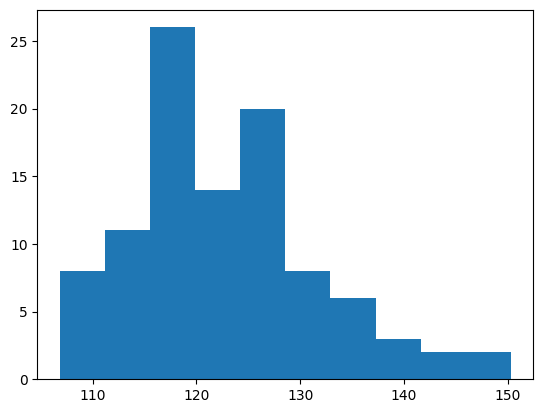

In [51]:
plt.hist(l2_error)

In [53]:
np.mean(l2_error), np.std(l2_error)

(122.75948234558105, 8.837369766485509)

(array([12., 12., 14., 14.,  8.,  9.,  8.,  8.,  8.,  7.]),
 array([0.40294921, 0.53107959, 0.65920997, 0.78734034, 0.91547072,
        1.0436011 , 1.17173147, 1.29986185, 1.42799222, 1.5561226 ,
        1.68425298]),
 <BarContainer object of 10 artists>)

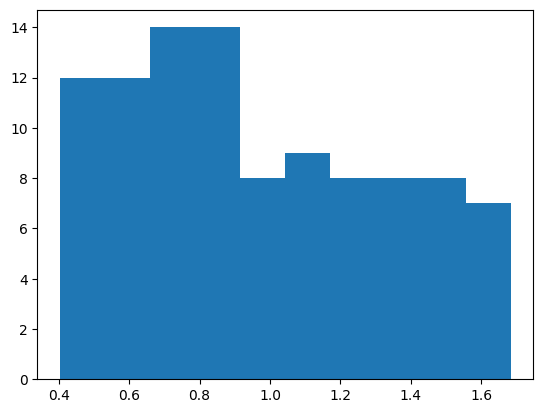

In [52]:
plt.hist(weighted_l2_error)

In [54]:
np.mean(weighted_l2_error), np.std(weighted_l2_error)

(0.9643064138293266, 0.35244023957886567)

In [91]:
l2_error_pad, weighted_l2_error_pad = defaultdict(list), defaultdict(list)

for _ in range(100):
	model = torch.nn.Sequential(
		torch.nn.Linear(2, 128),
		torch.nn.Softplus(),
		torch.nn.Linear(128, 128),
		torch.nn.Softplus(),
		torch.nn.Linear(128, 2))
	optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
	score = Score2d(
		model, 
		optimizer,
		BrownianDiffusionJoint(symmetric_gaussian_mixture_1d(), 4)
	)

	score.learn(
		n_samples_per_iter = 1000,
		n_iters = 500,
		keep_best = True 
	)
	
	# ground truth score
	g = torch.arange(-10, 10, 0.1)
	g.requires_grad = True
	log_prob = mixture.log_prob(g)
	prob = log_prob.exp().detach()
	log_prob.sum().backward()

	# approx score
	for i in np.arange(0, 1, 0.1):
		i = np.around(i, 1)
		t = torch.zeros_like(g) + i
		x = torch.stack((g, t)).T
		with torch.no_grad():
			s = score.model(x).T[0]
		
		l2_error_pad[i].append((s - g.grad).abs().sum().item())
		weighted_l2_error_pad[i].append(((s - g.grad).abs() @ prob).item())

100%|██████████| 500/500 [00:04<00:00, 101.26it/s]


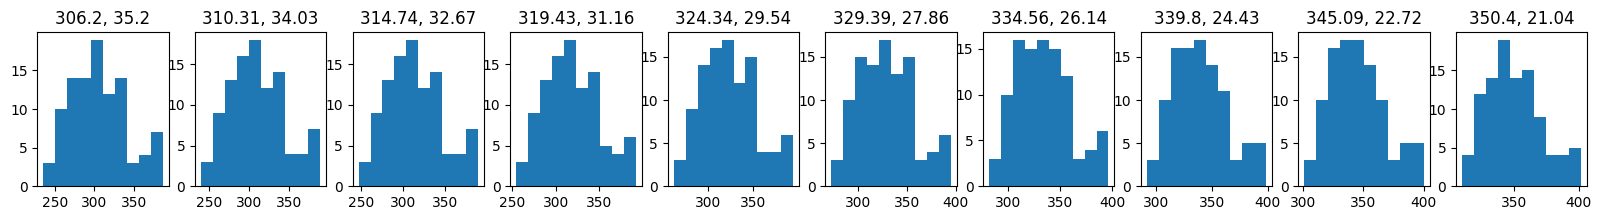

In [107]:
fig, axs = plt.subplots(1, len(l2_error_pad), figsize=(20, 2))
for i, (t, errs) in enumerate(l2_error_pad.items()):
	axs[i].hist(errs)
	axs[i].set_title(
		f'{np.around(np.mean(errs), 2)}, {np.around(np.std(errs), 2)}')

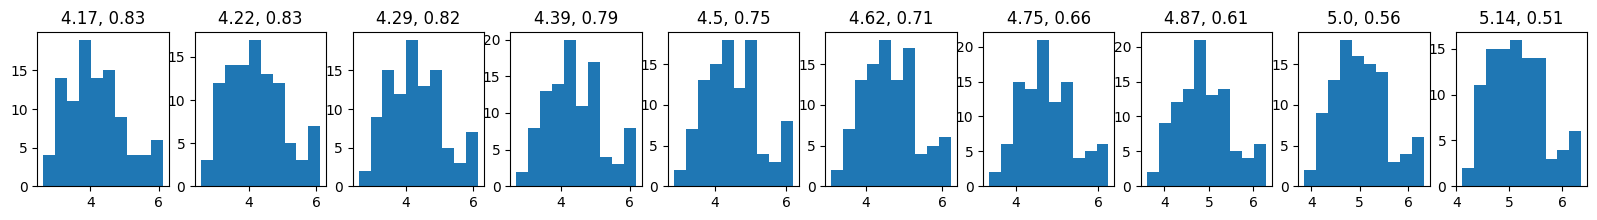

In [105]:
fig, axs = plt.subplots(1, len(weighted_l2_error_pad), figsize=(20, 2))
for i, (t, errs) in enumerate(weighted_l2_error_pad.items()):
	axs[i].hist(errs)
	axs[i].set_title(
		f'{np.around(np.mean(errs), 2)}, {np.around(np.std(errs), 2)}')